# Exploring the articles further

### Hypothesis about publication times

After the inital EDA performed on the articles in the [corpus notebook](./text/1.0-aw-corpus.ipynb), we noticed that there is an increase in articles published at 13:00 UTC, around the opening of the stock market. The question is what does this imply, and does this mean anything for our data. 

The main thing we should think about is what type of articles are being published at this time, specifically what they are actually talking about. The fact they are being published right at the opening of the stock market could imply that they are **describing changes in the market** instead of reporting on the company itself.

For example, an article which says 'Tesla shares fell 4% today' contain **the answer itself**, it doesn't provide any extra content or information which we can use to predict market movement since it is reporting on the market movement itself. If we were to label this article with returns for that same day, this would be redundant. The only exception is for continuation/reversal patterns or trends, however this isn't the focus for our model.

We have to remember the whole intention behind our model: To take articles which report on the **company, not the stock**, and be able to predict market movement from this data. Being able to flag articles which are *reactive and not proactive* would help our model achieve this goal.

### Aim

With this, we can create an algorithm which will take an article as its input, and return a binary value which corresponds to whether the article is proactive or not. This can be used in many ways for our model: as a feature or as a filter to remove reactive articles from our dataset.

Along with this, we can also produce a **score** for the reactivity, which would take a value between 0.0 and 1.0. This could be used specifically as a feature, and also allow us to gain further insights when performing further EDA later on. In the future, we can compare this to BERTtopic, which will likely discover a 'market recap' cluster on its own and see whether it is worth keeping, or even integrating the two together.

We need to make sure our algorithm is tested, which we will do by picking a sample of 100 articles, hand-labelling them, and running our algorithms and comparing results.

It would also be useful to create a market time feature, which separates all articles into (around) market opening, market closure, and all other times. This will allow us to test our original hypothesis by checking if there is any difference in the number of reactive articles depending what time they are posted.

### Note

In this notebook, we are focusing strictly on **Textual reactivity**, i.e. does the *language itself* reference a price move that has already happened. This means we do not need any price data for this, we are focusing strictly on the content of the articles.

We should also note that due to the way the timestamp alignment function is constructed, there should be no leakage since the label window always begins on the next trading day, meaning that even a reactive article shouldn't be able to see its own move.

Finally, let's give a concrete definition to what we mean by reactivity: We will label an article as reactive if the stock's recent price action is **the reason the article exists**. This is different to just mentioning the price of the stock, since many articles will mention a stock's price in passing while the main focus is on corporate events.

### One risk to consider

There is the risk that if we use our momentum feature and caluclate it for the day before, where the article reports on a move that has already occured, an unwanted correlation could arise purely by construction. This is not leakage but could still lead our sentiment labels to look more predictive than they actually are due to this correlation, which is referred to as a **confound**. We need to be careful how we use this feature once it is constructed.

### Setup

To begin, we load the raw corpus which contains all the articles fetched in the [corpus notebook](./text/1.0-aw-corpus.ipynb).

In [27]:
from stock_predictor.config import RAW_DATA_DIR, INTERIM_DATA_DIR
import pandas as pd

articles = pd.read_parquet(RAW_DATA_DIR / "raw_articles.parquet")
articles[["headline","summary", "source", "timestamp_utc"]].head()

,headline,summary,source,timestamp_utc
0,"'I Don't Buy Single Stocks,' Says Dave Ramsey....",,Benzinga,2025-08-31 13:00:00+00:00
1,Marjorie Taylor Greene Put Money In BlackRock'...,Rep. Marjorie Taylor Greene (R-Ga.) has added ...,Benzinga,2025-08-31 10:30:59+00:00
2,Market Efficiency Is Impossible: Here Is Why A...,Stock price efficiency is theoretically imposs...,SeekingAlpha,2025-08-31 09:00:00+00:00
3,Consumer Tech News (August 25–August 30): Nvid...,Despite a strong quarter from NVIDIA — now the...,Benzinga,2025-08-31 07:31:32+00:00
4,Analyst: Tesla (TLSA) Automotive Weakness Weig...,"Tesla, Inc. (NASDAQ:TSLA) is one of the AI Sto...",Yahoo,2025-08-30 14:13:30+00:00


### Sample

We need to take a sample of 100 articles to test the algorithm on. To begin with, let's take a random sample using the inbuilt `.sample()` function for pandas dataframes. We will have to check whether the sample contains a good spread of reactive and non-reactive articles, which we can do later. For now, We will use this with `random_state=13` for reproducibility.

In [28]:
sample = articles.sample(n=100, random_state=13)
sample.head()

,article_id,headline,summary,source,url,timestamp_utc
905,137588679,"Stocks to Watch Monday: Alibaba, Tesla, Alphab...","↗️ Alibaba (HK:9988, BABA): The Chinese e-comm...",Yahoo,https://finnhub.io/api/news?id=715da4f4550f670...,2025-11-24 11:51:07+00:00
806,138443021,"As Tesla Falters In China, This Local Rival Is...",Automaker Tesla Inc.&#39;s (NASDAQ: TSLA) mome...,Benzinga,https://finnhub.io/api/news?id=cc19c227f81ec46...,2025-11-26 05:54:46+00:00
1529,139225685,"CII: Remains Elevated In Valuation, Some Alter...",,SeekingAlpha,https://finnhub.io/api/news?id=b2b3effdcc181b7...,2026-02-25 17:44:28+00:00
814,137611100,Google is Winning the AI Race by Stealing Exxo...,Alphabet is transforming into the ‘Big Oil’ of...,Yahoo,https://finnhub.io/api/news?id=ce319e27a7968de...,2025-11-25 22:26:09+00:00
2309,140440610,Jensen Huang Joins Elite Tsinghua University A...,Nvidia Corp. (NASDAQ:NVDA) CEO Jensen Huang ha...,Yahoo,https://finnhub.io/api/news?id=b5d61698756f4ba...,2026-05-28 01:38:40+00:00


### Reg-Ex for pattern recognition

The approach we are going to take for our algorithm consists of a list of Reg-Ex statements which will contain words and phrases we are looking for when looking for reactivity. We will separate them into strong and weak patterns, where strong patterns represent near certain indicators of reporting on stock movement (i.e. "shares fell", "hits a new all-time high"), compared to weak patterns which will make some suggestion or imply some sort of report on stock movement (i.e. "here's why", "what's behind"). These patterns will be given different weightings accordingly when calculating the reactivity score.

We also recompile the patterns so that they are case-insensitive, since some article headlines may contain words in capital letters for dramatic effect. It is important to note that we include present tense movement verbs as well as past tense to cover as many possible headlines as possible.

In [29]:
import re

MOVE_VERBS = (
    r"(rises?|falls?|slides?|slips?|surges?|jumps?|climbs?|tumbles?|sinks?|sank|sunk|"
    r"gains?|drops?|plunges?|soars?|rallies?|retreats?|declines?|advances?|"
    r"rose|fell|slid|slipped|surged|jumped|climbed|tumbled|sank|"
    r"gained|dropped|plunged|soared|rallied|retreated|declined|advanced)"
)

STRONG_PATTERNS = [
    rf"\bshares?\s+(?:\w+\s+){{0,2}}{MOVE_VERBS}",
    rf"\bstock\s+(?:\w+\s+){{0,2}}{MOVE_VERBS}",
    r"\bstock\s+(closed|opened|traded|finished)\b",
    r"\b(up|down|off)\s+\d+(\.\d+)?\s*%",
    r"\b\d+(\.\d+)?\s*%\s+(higher|lower|gain|loss|drop|jump)",
    r"\bextend(s|ed|ing)?\s+(gains|losses|slide|rally)\b",
    r"\bhit(s|ting)?\s+(a\s+)?(new\s+)?(record|all-time)\s+(high|low)\b",
    r"\b(52|fifty-two)[- ]week\s+(high|low)\b",
]

WEAK_PATTERNS = [
    r"\b(rally|selloff|sell-off|slump|surge|plunge)\b",
    r"\bhere'?s\s+why\b",
    r"\binvestors?\s+(weighed|reacted|shrugged|cheered|punished)\b",
    r"\b(outperform|underperform)(ed|ing)?\s+the\s+(market|s&p|nasdaq)\b",
    r"\b(premarket|pre-market|after[- ]hours)\s+(trading|movers?)\b",
    r"\bmoving\s+(the\s+)?(market|stock)s?\b",
    r"\b(top|biggest)\s+(gainers?|losers?|movers?)\b",
    r"\bwhat'?s\s+(driving|behind)\b",
]

_STRONG = [re.compile(p, re.IGNORECASE) for p in STRONG_PATTERNS]
_WEAK = [re.compile(p, re.IGNORECASE) for p in WEAK_PATTERNS]

Let's test some phrases which should be flagged as patterns. 

In [30]:
strong_phrases = [
    "Stock rose in the last couple of weeks",
    "EXTENDED GAINS throughout month of June",
    "Tesla stock hits record low"
]

weak_phrases = [
    "Here's why investors should be concerned",
    "Tesla outperformed the market after recent earnings call",
    "TOP movers from the past week"
]

for phrase in strong_phrases:
    for pattern in _STRONG:
        result = pattern.search(phrase)
        if result:
            print(result.group())

for phrase in weak_phrases:
    for pattern in _WEAK:
        result = pattern.search(phrase)
        if result:
            print(result.group())

Stock rose
EXTENDED GAINS
hits record low
Here's why
outperformed the market
TOP movers


This will be tested more thoroughly once we have created the algorithms with some longer summaries and comparing them to an expected output score.

We can now contruct our algorithm.

### Conventions

It is important that we make distinctions between hits in the headline, summary and article itself. By nature, there will be more hits in the article itself if it is reactive in the first place, since the text will just be longer. However, we don't have access to the full articles yet, so this will be implemented later on.

Since the headlines and summaries should all be no longer than a single phrase or sentence (maybe a few), we do not differentiate them by this. However, they should still carry different weights, since a is usually where the news hook will be. Our strong patterns are the types of phrases that intend to grab the reader's attention, so it makes sense that they would be put in the headline.

It makes sense to put more weight to headline hits, since it would be strange for an article to not have a reactive headline but then have a reactive summary, so we would need more hits in the summary to actually convince us that the article is truly reactive. Let's set some numbers in stone:

- Headline strong hit: 1.0
- Headline weak hit: 0.5
- Summary strong hit: 1.0
- Summary weak hit: 0.25
- Article strong hit: 0.2
- Article weak hit: 0.1

We can always adjust these numbers after comparing with our own hand labels to make them more effective. We also need a threshold for which the reactive flag will be set to true. It makes sense to assume an article is reactive if there is a strong hit in the headline, so we set our threshold to **1.0** by default. However, once we gain access to the full articles, we can adjust the threshold by length of the article, so we will pass the threshold as an argument so it can be adjusted if necessary.

### Structure

The output of the will take the form of a dataclass, which will contain the reactive flag, reactive score and the actual hits themselves, since access to this will help with debugging or tuning later on. We will then have a method which will check for hits against our patterns, similarly to the code from earlier. The algorithm itself will then simply pull all of the hits, weight them accordingly and compute the score, returning the flag, score and the hits.

To make our life easier when validating our algorithm, we will create a function which generates a random sample based on a given seed (we will first use `random_seed=13` like in the example) and sample size. This function will export the sample into a csv file, which allows us to go through and easily handlabel the articles. We have to make sure to omit the score and the flag from our table so there is no bias when labelling. Finally, we will have an evalutation function, which will read the handlabelled table, run the classification method and evaluate the algorithm based on a few metrics which we will decide upon at construction.

### Evaluation

We can now proceed with hand labelling our sample.

In [31]:
from stock_predictor.text.reactive import make_labelling_sample, evaluate_sample

test_sample = make_labelling_sample(articles, 13)

Wrote 100 rows to C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor\data\interim\reactive_sample.csv — fill in true_label, then run evaluate().


Now with our hand labels in place, let's see what the spread of the sample is.

C:\Users\kacpe\AppData\Local\Temp\ipykernel_12544\974556655.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, palette="muted")


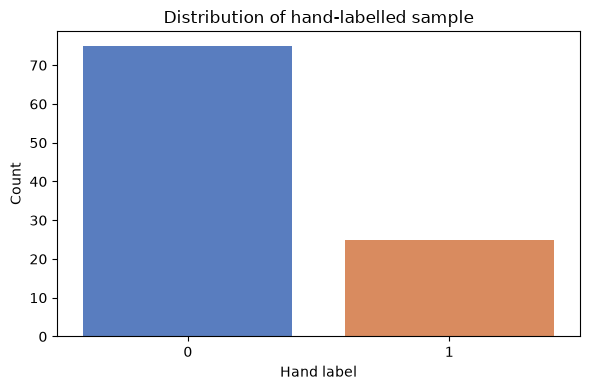

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

labelled_sample = pd.read_csv(INTERIM_DATA_DIR / "labelled_sample.csv")

labels = labelled_sample["hand_label"].dropna().astype(int)
counts = labels.value_counts().sort_index()

# Plot counts with percentage annotations
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, palette="muted")
ax.set_xlabel("Hand label")
ax.set_ylabel("Count")
ax.set_title("Distribution of hand-labelled sample")
plt.tight_layout()
plt.show()


We see that this particular sample favours much more towards non-reactive articles, with 75 non-reactive and 25 reactive articles. It would be interesting to try figure out whether this is just a case of a skewed sample, or our whole dataset has such a split, however this would require hand labelling thousands of articles, which is unrealistic for this project. For our purposes, This is a good enough split and provides a test of whether our algorithm can correctly identify reactive articles. Let's now run the evaluation to see how well our algorithm performs against the hand labels.

In [33]:
# Run the evaluation
metrics = evaluate_sample(
    INTERIM_DATA_DIR / "labelled_sample.csv",
    sample,
    threshold=1.0
)


Agreement 80.00% on n=100 (precision 77.78%, recall 28.00%)

20 disagreements:
  [hand label=1 algo label=0.0] Stocks to Watch Monday: Alibaba, Tesla, Alphabet, Bayer
  [hand label=1 algo label=0.0] Tech stocks see a big rebound on Powell speech
  [hand label=1 algo label=0.0] 1 Cash-Burning Stock with Promising Prospects and 2 We Avoid
  [hand label=1 algo label=0.0] Overseas Markets Outperformed US YTD; China Exuberance Fuels Buying
  [hand label=1 algo label=0.0] Tesla's Stock Just Bounced Back in a Big Way. Here's Where Traders See It Going Next
  [hand label=1 algo label=0.0] Tesla (TSLA) Stock Is Up, What You Need To Know
  [hand label=1 algo label=0.0] These Were the Best and Worst S&P 500 Stocks in April
  [hand label=1 algo label=0.0] ETV: Decent Price Right Now, But Not As Diversified As I Would Like
  [hand label=1 algo label=0.0] Tesla Call Feels Like A Reality Check
  [hand label=1 algo label=0.0] 10 Stocks Rocketing After Powell's Dovish Shift
  [hand label=0 algo label=1

### Initial comments

From having a first look at the articles which were mislabelled by the algorithm, we can clearly see that there are many more articles not being caught as reactive rather than labelling non reactive articles as reactive. This former outcome is more desriable than the latter simply because the size of our dataset is fairly high, so if we were to use this feature as a filter to remove reactive articles from our dataset, we would simply be leaving in some reactive articles, which is less harmful compared to removing lots of good quality data in non-reactive articles.

Our algorithm already covers a lot of ground in terms of our established patterns: it could be a good idea to add these missed articles to our pattern list somehow, however this would only be deceptively improving our algorithm as it would only take care of these specific phrases. It would be impossible to cover every single pattern in such a way. Maybe it would be more efficient to use an ML model, like BERTtopic, to label the articles more efficiently. However, for the timebeing we will use our algorithm as it still has a fairly high accuracy.

### Performance Analysis

Now we will calculate some evaluation metrics which will show how well our algorithm performs on the hand-labelled sample. These are the key metrics to consider:

- **Agreement**: The overall accuracy of our algorithm (the amount of correctly identified articles)
- **Precision**: Of the articles our algorithm flagged as reactive, how many actually were (TP / (TP + FP))
- **Recall**: Of the truly reactive articles, how many did our algorithm catch (TP / (TP + FN))

Let's examine the detailed metrics and understand where our algorithm might be falling short or excelling.


In [34]:
#Visualize the performance metrics
print("EVALUATION METRICS SUMMARY")
print(f"\nSample Size: {metrics['n']}")
print(f"Overall Agreement: {metrics['agreement']:.2%}")
print(f"\nPrecision (True Positives / Predicted Positives): {metrics['precision']:.2%}")
print(f"Recall (True Positives / Actual Positives): {metrics['recall']:.2%}")
print(f"\nBase Rate (Algorithm): {metrics['base_rate_pred']:.2%}")
print(f"Base Rate (True Labels): {metrics['base_rate_true']:.2%}")


EVALUATION METRICS SUMMARY

Sample Size: 100
Overall Agreement: 80.00%

Precision (True Positives / Predicted Positives): 77.78%
Recall (True Positives / Actual Positives): 28.00%

Base Rate (Algorithm): 9.00%
Base Rate (True Labels): 25.00%


We see that our algorithm has a high agreement rate of 80%, which looks promising. However, the recall is alarmingly low, which as we said comes from the high number of articles not being correctly identified as reactive. 

Let's visualise our confusion matrix with a heatmap. The confusion matrix breaks down into:
- **TP (True Positives)**: Correctly identified reactive articles
- **TN (True Negatives)**: Correctly identified non-reactive articles
- **FP (False Positives)**: Incorrectly flagged non-reactive articles as reactive
- **FN (False Negatives)**: Missed reactive articles

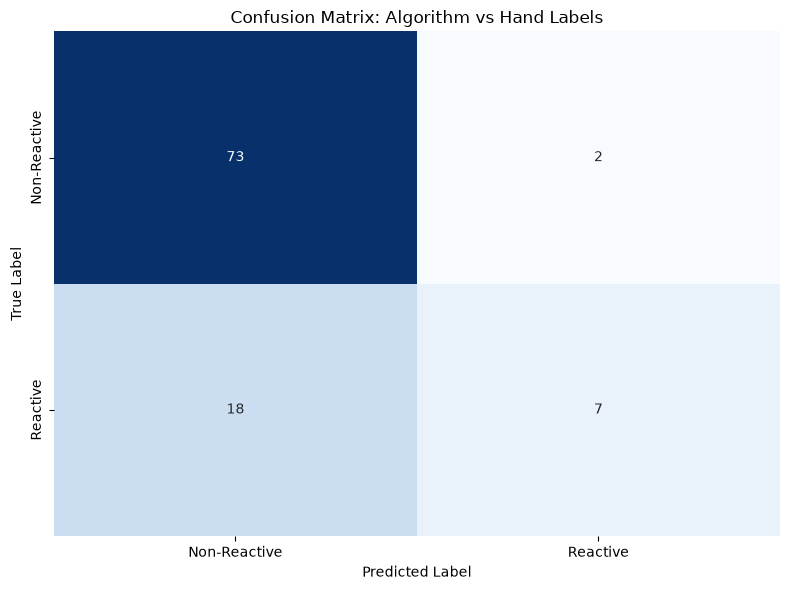

In [35]:
# Use the already-computed evaluation results rather than reloading the CSV
# and re-running the classifier on the same sample.
import numpy as np
from sklearn.metrics import classification_report

conf = metrics["confusion"]
cm = np.array([
    [conf["tn"], conf["fp"]],
    [conf["fn"], conf["tp"]],
])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    cbar=False,
    xticklabels=['Non-Reactive', 'Reactive'],
    yticklabels=['Non-Reactive', 'Reactive'],
)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix: Algorithm vs Hand Labels')
plt.tight_layout()
plt.show()

### Threshold Optimization

One way that we can attempt to improve algorithm performance is to adjust the decision threshold. Currently we use a threshold of 1.0 (a single headline strong pattern hit is enough). 

However, in our case, the main issue didn't seem to be with the threshold, since the articles which were not flagged ended up having a score of 0 anyway, meaning that there weren't any patterns found. This means that we cannot make any meaningful adjustments to the threshold. 

We can go about optimizing the threshold once we take into account the full articles, since it is more likely for there to be hits compared to now where a lot of articles didn't have any. 

## Summary

This notebook successfully completed the evaluation of our reactivity algorithm. Here's what we accomplished:

### What We Built
- **Regex-based reactivity classifier** that identifies articles reporting on stock price movements rather than underlying company fundamentals
- **Weighted scoring system** that distinguishes between strong patterns (e.g., "shares fell") and weak patterns (e.g., "here's why")
- **Hand-labelled validation dataset** of 100 articles with binary reactivity labels

### Next Steps for Production
1. Apply this classifier to the full article corpus to create a reactivity feature, and perform further analysis including threshold tuning
2. Once algorithm is fully deployed and optimized, compare to the publishing time to test our original hypothesis
3. Combine with other features (timestamp, sentiment, market indicators) for predictive modeling
4. Monitor performance on out-of-sample data and refine patterns as needed
5. Integrate with BERTopic analysis to compare topic-based vs. pattern-based reactivity detection